# Experiemnt record - Diffusion-`MNIST`

## Environment

### install

#### install torch 2.2 -suppoort mac-intel-x86_64

In [6]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


#### install diffusers and transformers default - might not be compatible

In [8]:
pip install diffusers transformers accelerate

Note: you may need to restart the kernel to use updated packages.


#### install diffusers -not support xpu 

In [11]:
pip install diffusers==0.29.2

Note: you may need to restart the kernel to use updated packages.


#### install transformers -support torch

In [13]:
pip install transformers==4.45.2

Note: you may need to restart the kernel to use updated packages.


#### install ipywidgets -support visualization of process 

In [ ]:
pip install ipywidgets

#### install numpy - support transformer

In [3]:
pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp312-cp312-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_10_9_x86_64.whl (20.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## library

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler
import numpy as np
import random
from tqdm import tqdm
import glob
import re
import matplotlib.pyplot as plt


### configration

In [7]:
test_cpu = "cpu"

## diffusion test-`MNIST`

In [2]:
# init seed
def init_seed(seed = 42):
    torch.manual.seed(seed)
    np.random.seed(seed)
    random_seed(seed)
    

### data preparation

In [3]:

def create_mini_puzzle(puzz_img):
    # images: [1, 28, 28] -> 2x2 patches
    img_patches = puzz_img.unfold(1, 14, 14).unfold(2, 14, 14)
    img_patches = img_patches.contiguous().view(1, 4, 14, 14)
    
    # original order
    target_order = torch.tensor([-3.0, -1.0, 1.0, 3.0])
    
    # random
    shuffle_idx = torch.randperm(4)
    shuffled_patches = img_patches[:, shuffle_idx]
    
    return shuffled_patches.squeeze(0), target_order,shuffle_idx

puzz_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # normlized to [-1, 1]
])

train_mini_dataset = datasets.MNIST(root = './data', train = True, download = True, transform = puzz_transform)

class PuzzleDataset(torch.utils.data.Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset
    def __len__(self):
        return len(self.mnist)
    def __getitem__(self, idx):
        img, _ = self.mnist[idx]
        shuffled, target, _ = create_mini_puzzle(img)
        # shuffled
        return shuffled, target
        
train_loader = DataLoader(PuzzleDataset(train_mini_dataset), batch_size = 64, shuffle = True)   
    

### feature extractor

In [5]:

class FragFeatureExtractor(nn.Module):
    """ 14x14-> 64 dimention vector"""
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2), #14x14->7x7
            nn.Conv2d(16, 32, 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2), #7x7->3x3
            nn.Flatten(),
            nn.Linear(32 * 3 * 3, 64),
            nn.ReLU()
        )
    def forward(self, patches):
        B, N, H, W = patches.shape
        patches = patches.view(B * N, 1, H, W) 
        frag_features = self.cnn(patches)
        frag_features = frag_features.view(B, N, 64)
        return frag_features

### tiny UNet

In [11]:
class ConditionedUNet(nn.Module):
    """ predict the diffusion model for 2x2  puzzles"""
    def __init__(self):
        super().__init__()
        # potional encoder for noisy position and timestep
        self.time_mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )
        # contion fusion, fragment -> 128 dimentions
        self.cond_proj = nn.Linear(64, 32)

        # 2D-unet
        self.conv_in = nn.Conv2d(33, 64, 3, padding=1)
        self.norm_in = nn.BatchNorm2d(64)
        
        self.conv_mid1 = nn.Conv2d(64, 64, 3, padding=1)
        self.norm_mid1 = nn.BatchNorm2d(64)

        self.conv_mid2 = nn.Conv2d(64, 64, 3, padding=1)
        self.norm_mid2 = nn.BatchNorm2d(64)

        self.conv_out = nn.Conv2d(64, 1, 3, padding=1)
        self.relu = nn.ReLU()
        
    def forward(self, noisy_positions, timesteps, condition):
        """
        Args:
            noisy_positions: [B, 4]position with noise
            timesteps: [B]timesteps
            condition: [B, 4, 64]fragment feature                 
        """
        B = noisy_positions.shape[0]

        # 1d vector -> 2x2 grid
        pos_map = noisy_positions.view(B, 1, 2, 2)
        # each fragment -> 32d, 2x2
        cond_feat = self.cond_proj(condition)
        cond_map = cond_feat.permute(0, 2, 1)
        cond_map = cond_map.reshape(B, 32, 2, 2)

        x = torch.cat([pos_map, cond_map], dim = 1)
        
        # timestep encoder
        ts = timesteps.float().view(B, 1)/1000.0 #[B, 1]
        time_embedding = self.time_mlp(ts)
        time_embedding = time_embedding.view(B, 64, 1, 1) #[B, 4, 128]
        
        # forward
        x = self.conv_in(x)
        x = self.norm_in(x)
        x = x + time_embedding
        x = self.relu(x)

        x = self.conv_mid1(x)
        x = self.norm_mid1(x)
        x = x + time_embedding
        x = self.relu(x)
        
        x = self.conv_mid2(x)
        x = self.norm_mid2(x)
        x = x + time_embedding
        x = self.relu(x)

        x = self.conv_out(x)
        x = torch.tanh(x) * 3.5

        # unpack
        noise_prediction = x.reshape(B, 4)
        
        return noise_prediction
        

In [172]:
#tese net
model_test = ConditionedUNet()
test_B = 4
test_pos = torch.randn(test_B, 4)
test_time = torch.randint(0, 1000, (test_B,))
test_cond = torch.randn(test_B, 4, 64)
test_output = model_test(test_pos, test_time, test_cond)
print(f"shape: {test_output.shape}")


shape: torch.Size([4, 4])


In [ ]:
"""
puzz_unet = UNet2DConditionModel(
    sample_size = 4,
    in_channels = 4,
    out_channels = 4,
    layers_per_block = 1,
    block_out_channels = (32, 64),
    down_block_types = ("CrossAttnDownBlock2D", "DownBlock2D"),
    up_block_types = ("CrossAttnUpBlock2D", "UpBlock2D"),
)
"""

### training

In [13]:
# training
device = 'cpu'
frag_feature_extractor = FragFeatureExtractor().to(device)
puzz_unet = ConditionedUNet().to(device)

puzz_scheduler = DDPMScheduler(num_train_timesteps = 1000, beta_schedule='squaredcos_cap_v2')
puzz_optimizer = optim.Adam(list(puzz_unet.parameters())+list(frag_feature_extractor.parameters()), lr = 1e-4)

# start
print("=====training start=====")
for epoch in range(30): # time
    
    epoch_loss = 0
    process_bar = tqdm(train_loader, desc = f"Epoch {epoch+1}/30")
    
    for shuffled_patches, target_pos in process_bar:
        shuffled_patches = shuffled_patches.to(device) #[B, 4, 14, 14]
        target_pos = target_pos.to(device).float() #[B, 4]
        
        ## feature of fragment as condition
        patch_features = frag_feature_extractor(shuffled_patches)
        
        ## add noise
        puzz_noise = torch.randn_like(target_pos)
        timesteps = torch.randint(0, 1000, (target_pos.shape[0],), device = device)
        noisy_pos = puzz_scheduler.add_noise(target_pos, puzz_noise, timesteps)
        
        # prediction of noise
        noise_pred = puzz_unet(noisy_pos, timesteps, patch_features)
        
        # calculation of loss
        foward_loss = nn.MSELoss()(noise_pred, puzz_noise)
        
        # backward
        puzz_optimizer.zero_grad()
        foward_loss.backward()
        puzz_optimizer.step()
        epoch_loss += foward_loss.item()
        process_bar.set_postfix({'loss':foward_loss.item()})
    print(f"Epoch {epoch+1} mean loss:{epoch_loss/len(train_loader):.4f}")
    
    if (epoch + 1) % 5 == 0 :
        torch.save({'unet': puzz_unet.state_dict(),
                   'feature_extractor': frag_feature_extractor.state_dict()
                   } ,f'mnist/puzzle_model_epoch_{epoch+1}.pt')
    

=====training start=====


Epoch 1/30: 100%|███████████████| 938/938 [00:39<00:00, 23.89it/s, loss=0.0948]


Epoch 1 mean loss:0.1087


Epoch 2/30: 100%|███████████████| 938/938 [00:39<00:00, 23.60it/s, loss=0.0176]


Epoch 2 mean loss:0.0553


...

Epoch 28 mean loss:0.0121


Epoch 29/30: 100%|██████████████| 938/938 [00:48<00:00, 19.33it/s, loss=0.0123]


Epoch 29 mean loss:0.0118


Epoch 30/30: 100%|██████████████| 938/938 [00:46<00:00, 20.11it/s, loss=0.0098]

Epoch 30 mean loss:0.0115


#### test path

In [23]:
import os
print("os:",os.getcwd())

os: /Users/langyanxia/construction_RePair/construction-of-2.5D-RePAIR/notebook


In [27]:
torch.save({'hello'} ,f'mnist_output/puzzle_model_epoch_hello.pt')

### validation

In [33]:

def reconstruction(model, feature_extractor, scheduler, shuffled_patches, numsteps = 50):
    """
    input: shuffled_patches[4, 14, 14] a image consists of 4 fragements
    output: prediction of target order [4]
    """
    device = next(model.parameters()).device
    model.eval()
    feature_extractor.eval()

    with torch.no_grad():
        patches_batch = shuffled_patches.unsqueeze(0) #[1, 4, 14, 14]
        patch_features = feature_extractor(patches_batch) #[1, 4, 64]
        # start with full noise
        positions = torch.randn(1, 4, device = device)
        # puzz_scheduler timestep
        scheduler.set_timesteps(numsteps)
        for timestep in scheduler.timesteps:
            # predict noise
            noise_pred = model(positions,timestep.unsqueeze(0).expand(1), patch_features)
            # denoise
            positions = scheduler.step(noise_pred, timestep, positions).prev_sample
    raw_position_pred = positions.squeeze(0).cpu().numpy()
    #centers = [-3.0, -1.0, 1.0, 3.0]
    sorted_indices = np.argsort(raw_position_pred)
    final_order = np.zeros(4, dtype=int)
    #pred_idx = np.argmin(np.abs(raw_position_pred[:, None] - centers), axis=1)
    for rank, idx, in enumerate(sorted_indices): 
        final_order[idx] = rank
    
    #pred_pos = torch.round(positions).clamp(0, 3).int().squeeze(0)
    return final_order #pred_pos.cpu().numpy()

In [39]:
#test
print("======test inference=====")
test_img, _ = train_mini_dataset[24]
shuffled, target, shuffle_idx = create_mini_puzzle(test_img)
print(f"random position:{shuffle_idx.numpy()}")
print(f"real position:{target.numpy()}")

predition_order = reconstruction(puzz_unet, frag_feature_extractor, puzz_scheduler,shuffled, numsteps = 100)
print(f"prediced order of model:{predition_order}")

if np.array_equal(predition_order, target.numpy()):
    print("perfect")
else:
    print("accuracy to improve")

======test inference=====
random position:[1 0 3 2]
real position:[-3. -1.  1.  3.]
prediced order of model:[0 1 2 3]
accuracy to improve


## diffusion test-`MNIST` 3x3

### data preparation

In [69]:

def create_mini_puzzle_3x3(puzz_img):
    """
    input: [1, 27, 27] -> 3x3 block, each block 9x9
    return: shuffled_patches[9, 9, 9] target_position [9], shuffle_idx[9]
    """

    img_patches = puzz_img.unfold(1, 9, 9).unfold(2, 9, 9)
    img_patches = img_patches.contiguous().view(1, 9, 9, 9)
    
    # original order
    target_order = torch.tensor([-4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0])
    
    # random
    shuffle_idx = torch.randperm(9)
    shuffled_patches = img_patches[:, shuffle_idx]
    
    return shuffled_patches.squeeze(0), target_order,shuffle_idx

puzz_transform_3x3 = transforms.Compose([
    transforms.Resize((27, 27)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # normlized to [-1, 1]
])

train_mini_dataset_3x3 = datasets.MNIST(root = './data', train = True, download = True, transform = puzz_transform_3x3)

class PuzzleDataset_3x3(torch.utils.data.Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset
    def __len__(self):
        return len(self.mnist)
    def __getitem__(self, idx):
        img, _ = self.mnist[idx]
        shuffled, target, _ = create_mini_puzzle_3x3(img)
        # shuffled
        return shuffled, target
        
train_loader_3x3 = DataLoader(PuzzleDataset_3x3(train_mini_dataset_3x3), batch_size = 64, shuffle = True)   

### feature extractor

In [71]:

class FragFeatureExtractor_3x3(nn.Module):
    """ 14x14-> 64 dimention vector"""
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2), #9x9->4x4
            nn.Conv2d(16, 32, 3, padding = 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), #7x7->3x3
            nn.Flatten(),
            nn.Linear(32, 64),
            nn.ReLU()
        )
    def forward(self, patches):
        B, N, H, W = patches.shape
        patches = patches.view(B * N, 1, H, W) 
        frag_features = self.cnn(patches)
        frag_features = frag_features.view(B, N, 64)
        return frag_features

### lightweight net

In [73]:
class ConditionedUNet_3x3(nn.Module):
    """ predict the diffusion model for 2x2  puzzles"""
    def __init__(self):
        super().__init__()
        self.grid_size = 3
        self.num_patches = 9
        
        # potional encoder for noisy position and timestep
        self.time_mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )
        # contion fusion, fragment -> 64 dimentions
        self.cond_proj = nn.Linear(64, 64)

        # 2D-unet
        self.conv_in = nn.Conv2d(65, 64, 3, padding=1)
        self.norm_in = nn.BatchNorm2d(64)
        
        self.conv_mid1 = nn.Conv2d(64, 64, 3, padding=1)
        self.norm_mid1 = nn.BatchNorm2d(64)

        self.conv_mid2 = nn.Conv2d(64, 64, 3, padding=1)
        self.norm_mid2 = nn.BatchNorm2d(64)

        self.conv_out = nn.Conv2d(64, 1, 3, padding=1)
        self.relu = nn.ReLU()
        
    def forward(self, noisy_positions, timesteps, condition):
        """
        Args:
            noisy_positions: [B, 4]position with noise
            timesteps: [B]timesteps
            condition: [B, 4, 64]fragment feature                 
        """
        B = noisy_positions.shape[0]

        # [B, 9] -> [B, 1, 3, 3]
        pos_map = noisy_positions.view(B, 1, 3, 3)
        
        # [B, 9, 64] -> [B, 64, 3, 3]
        cond_feat = self.cond_proj(condition)
        cond_map = cond_feat.permute(0, 2, 1)
        cond_map = cond_map.reshape(B, 64, 3, 3)

        x = torch.cat([pos_map, cond_map], dim = 1)
        
        # timestep encoder
        ts = timesteps.float().view(B, 1)/1000.0 #[B, 1]
        time_embedding = self.time_mlp(ts)
        time_embedding = time_embedding.view(B, 64, 1, 1) #[B, 4, 128]
        
        # forward
        x = self.conv_in(x)
        x = self.norm_in(x)
        x = x + time_embedding
        x = self.relu(x)

        x = self.conv_mid1(x)
        x = self.norm_mid1(x)
        x = x + time_embedding
        x = self.relu(x)
        
        x = self.conv_mid2(x)
        x = self.norm_mid2(x)
        x = x + time_embedding
        x = self.relu(x)

        x = self.conv_out(x)
        x = torch.tanh(x) * 4.5

        # unpack
        noise_prediction = x.reshape(B, 9)
        
        return noise_prediction
        

### Training

In [77]:
# training
device = 'cpu'
frag_feature_extractor = FragFeatureExtractor_3x3().to(device)
puzz_unet = ConditionedUNet_3x3().to(device)

puzz_scheduler = DDPMScheduler(num_train_timesteps = 1000, beta_schedule='squaredcos_cap_v2')
puzz_optimizer = optim.Adam(list(puzz_unet.parameters())+list(frag_feature_extractor.parameters()), lr = 1e-4)

In [79]:


# start
print("=====training start=====")
for epoch in range(50): # time
    
    epoch_loss = 0
    process_bar = tqdm(train_loader_3x3, desc = f"Epoch {epoch+1}/30")
    
    for shuffled_patches, target_pos in process_bar:
        shuffled_patches = shuffled_patches.to(device) #[B, 4, 14, 14]
        target_pos = target_pos.to(device).float() #[B, 4]
        
        ## feature of fragment as condition
        patch_features = frag_feature_extractor(shuffled_patches)
        
        ## add noise
        puzz_noise = torch.randn_like(target_pos)
        timesteps = torch.randint(0, 1000, (target_pos.shape[0],), device = device)
        noisy_pos = puzz_scheduler.add_noise(target_pos, puzz_noise, timesteps)
        
        # prediction of noise
        noise_pred = puzz_unet(noisy_pos, timesteps, patch_features)
        
        # calculation of loss
        foward_loss = nn.MSELoss()(noise_pred, puzz_noise)
        
        # backward
        puzz_optimizer.zero_grad()
        foward_loss.backward()
        puzz_optimizer.step()
        epoch_loss += foward_loss.item()
        process_bar.set_postfix({'loss':foward_loss.item()})
    print(f"Epoch {epoch+1} mean loss:{epoch_loss/len(train_loader_3x3):.4f}")
    
    if (epoch + 1) % 5 == 0 :
        torch.save({'unet': puzz_unet.state_dict(),
                   'feature_extractor': frag_feature_extractor.state_dict()
                   } ,f'mnist/puzzle_model_epoch_{epoch+1}.pt')
    

=====training start=====


Epoch 1/30: 100%|███████████████| 938/938 [00:49<00:00, 18.97it/s, loss=0.0724]


Epoch 1 mean loss:0.1586


Epoch 2/30: 100%|███████████████| 938/938 [00:50<00:00, 18.56it/s, loss=0.0549]


Epoch 2 mean loss:0.0712


...

Epoch 48 mean loss:0.0109


Epoch 49/30: 100%|█████████████| 938/938 [00:51<00:00, 18.08it/s, loss=0.00928]


Epoch 49 mean loss:0.0095


Epoch 50/30: 100%|█████████████| 938/938 [00:48<00:00, 19.28it/s, loss=0.00492]

Epoch 50 mean loss:0.0094


### valiadation

In [199]:

def reconstruction_3x3(model, feature_extractor, scheduler, shuffled_patches, numsteps = 50):
    """
    input: shuffled_patches[4, 14, 14] a image consists of 4 fragements
    output: prediction of target order [4]
    """
    device = next(model.parameters()).device
    model.eval()
    feature_extractor.eval()

    with torch.no_grad():
        patches_batch = shuffled_patches.unsqueeze(0) #[1, 4, 14, 14]
        patch_features = feature_extractor(patches_batch) #[1, 4, 64]
        # start with full noise
        positions = torch.randn(1, 9, device = device)
        # puzz_scheduler timestep
        scheduler.set_timesteps(numsteps)
        for timestep in scheduler.timesteps:
            # predict noise
            noise_pred = model(positions,timestep.unsqueeze(0).expand(1), patch_features)
            # denoise
            positions = scheduler.step(noise_pred, timestep, positions).prev_sample
    raw_position_pred = positions.squeeze(0).cpu().numpy()

    sorted_indices = np.argsort(raw_position_pred)
    final_order = np.zeros(9, dtype=int)

    for rank, idx, in enumerate(sorted_indices): 
        final_order[idx] = rank
    
    return final_order, sorted_indices 

In [201]:
#test
print("======test inference=====")
test_img, _ = train_mini_dataset_3x3[900]
shuffled, target, shuffle_idx = create_mini_puzzle_3x3(test_img)
print(f"random position:{shuffle_idx.numpy()}")
print(f"real position:{target.numpy()}")

predition_order, prediction_value = reconstruction_3x3(puzz_unet, frag_feature_extractor, puzz_scheduler,shuffled, numsteps = 100)
print(f"prediced order of model:{predition_order}")

if np.array_equal(predition_order, np.argsort(target.numpy())):
    print("perfect")
else:
    print("accuracy to improve")

======test inference=====
random position:[5 7 0 4 1 6 8 2 3]
real position:[-4. -3. -2. -1.  0.  1.  2.  3.  4.]
prediced order of model:[0 1 2 3 4 5 6 7 8]
perfect


### evaluate checkpoints

find 10 checkpoints: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

=====test epoch {epoch}====
accuarcy:1/20 = 5.0%
loss:4.0/20 = 20.0%
accuarcy:2/20 = 10.0%
loss:8.0/20 = 40.0%
accuarcy:3/20 = 15.0%
loss:12.0/20 = 60.0%
accuarcy:4/20 = 20.0%
loss:16.0/20 = 80.0%
accuarcy:5/20 = 25.0%
loss:20.0/20 = 100.0%
accuarcy:6/20 = 30.0%
loss:24.0/20 = 120.0%
accuarcy:7/20 = 35.0%
loss:28.0/20 = 140.0%
accuarcy:8/20 = 40.0%
loss:32.0/20 = 160.0%
accuarcy:9/20 = 45.0%
loss:36.0/20 = 180.0%
accuarcy:10/20 = 50.0%
loss:40.0/20 = 200.0%
accuarcy:11/20 = 55.0%
loss:44.0/20 = 220.0%
accuarcy:12/20 = 60.0%
loss:48.0/20 = 240.0%
accuarcy:13/20 = 65.0%
loss:52.0/20 = 260.0%
accuarcy:14/20 = 70.0%
loss:56.0/20 = 280.0%
accuarcy:15/20 = 75.0%
loss:60.0/20 = 300.0%
accuarcy:16/20 = 80.0%
loss:64.0/20 = 320.0%
accuarcy:17/20 = 85.0%
loss:68.0/20 = 340.0%
accuarcy:18/20 = 90.0%
loss:72.0/20 = 360.0%
accuarcy:19/20 = 95.0%
loss:76.0/20 = 380.0%
accuarcy:20/20 = 100.0%
loss:80.0/20 = 400.0%

=====test epoch {epoch}=

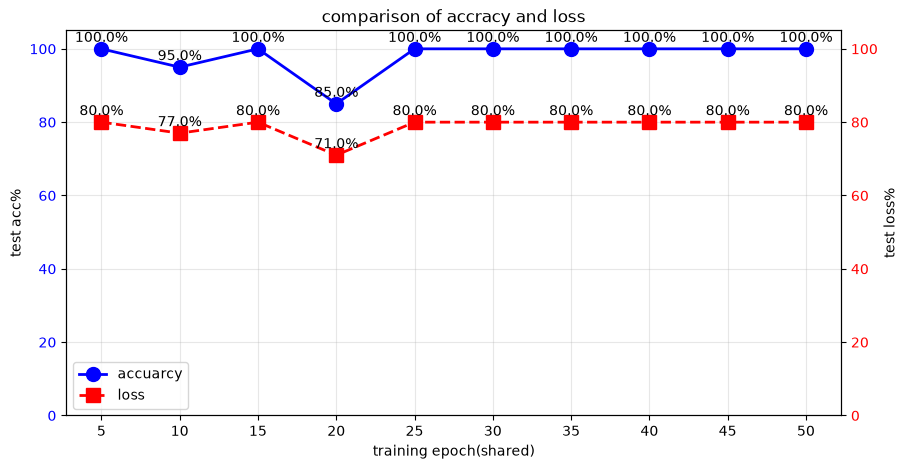

best model: epoch5 (accuarcy:100.0%)
best model loaded:mnist/puzzle_model_epoch_5.pt


In [246]:


# 1. load all checkpoints
pt_files = glob.glob('mnist/puzzle_model_epoch_*.pt')
checkpoints = []
for pt in pt_files:
    num = int(re.search(r'epoch_(\d+)', pt).group(1))
    checkpoints.append((num, pt))
checkpoints.sort()
print(f"find {len(checkpoints)} checkpoints: {[c[0] for c in checkpoints]}")

#2. data preparation for test
test_size = 20
test_dataset = train_mini_dataset_3x3
test_images = [test_dataset[i] for i in range(test_size)]
#3. test
results = {} #{epoch: accuracy}

for epoch, filepath in checkpoints:
    print("\n=====test epoch {epoch}====")
    # load model
    checkpoint = torch.load(filepath, map_location = device)
    puzz_unet.load_state_dict(checkpoint['unet'])
    frag_feature_extractor.load_state_dict(checkpoint['feature_extractor'])
    puzz_unet.eval()
    frag_feature_extractor.eval()
    correct = 0
    value_loss = 0
    for idx, (img, label) in enumerate(test_images):
        # generate puzzle
        shuffled, target,shuffle_idx = create_mini_puzzle_3x3(img)
        # inferenc
        pred, pred_value = reconstruction_3x3(puzz_unet, frag_feature_extractor, puzz_scheduler, shuffled, numsteps = 50)
        target_value = target.numpy()
        if np.array_equal(pred, np.argsort(target_value)):
            correct += 1
            value_loss += np.mean(np.abs(np.subtract(pred_value, target_value)))
        else:
            value_loss += 1
        acc = correct / test_size * 100
        loss = value_loss / test_size * 100
        results[epoch] = [acc, value_loss]
        print(f"accuarcy:{correct}/{test_size} = {acc:.1f}%")
        print(f"loss:{value_loss}/{test_size} = {loss:.1f}%")
#4. plot
epochs = sorted(results.keys())
accs = [results[e][0] for e in epochs]
losses = [results[e][1] for e in epochs]
fig, ax1 = plt.subplots(figsize = (10, 5))
ax1.plot(epochs, accs, marker = 'o', linewidth=2, markersize=10, color = 'b', label = 'accuarcy')

ax1.set_xlabel('training epoch(shared)')
ax1.set_ylabel('test acc%')
ax1.tick_params(axis = 'y', labelcolor = 'b')
ax1.grid(True, alpha = 0.3)
for e, a in zip(epochs, accs):
    plt.text(e, a+1, f'{a:.1f}%', va = 'bottom', ha = 'center')
ax1.set_ylim(0, 105)



ax2 = ax1.twinx()
ax2.plot(epochs, losses, marker = 's', linestyle = '--', linewidth=2, markersize=10, color = 'r', label = 'loss')
for e, l in zip(epochs, losses):
    plt.text(e, l+1, f'{l:.1f}%', va = 'bottom', ha = 'center')
ax2.set_ylabel('test loss%')
ax2.set_ylim(0, 105)
ax2.tick_params(axis = 'y', labelcolor = 'r')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2)
plt.title('comparison of accracy and loss')
plt.xticks(epochs)
plt.show()

#5.best model
best_epoch = max(results, key = lambda k : results[k][0])
best_acc = results[best_epoch][0]
print(f"best model: epoch{best_epoch} (accuarcy:{best_acc:.1f}%)")

# load best model
best_file = f'mnist/puzzle_model_epoch_{best_epoch}.pt'
checkpoint = torch.load(best_file, map_location=device)
puzz_unet.load_state_dict(checkpoint['unet'])
frag_feature_extractor.load_state_dict(checkpoint['feature_extractor'])
print(f"best model loaded:{best_file}")



### visualization of the changed image in the process of reconstruction

In [248]:
def visualize_reconstruction(raw_img, shuffled_patches,shuffled_idx,pred_order,grid_size=3):
    """ show raw image vs random vs reconstruct

    Args:
        - raw img: the origin image
        - shuffled_patches: the shuffled fragment 
        - pred_order: the predicted order
        - grid_size: size of split
    """
    N = grid_size * grid_size
    patch_h, patch_w = shuffled_patches.shape[1], shuffled_patches.shape[2]

    # construct shuffled image
    shuffled_grid = np.zeros((grid_size * patch_h, grid_size * patch_w))
    for idx in range(N):
        r, c = divmod(idx, grid_size)
        shuffled_grid[r*patch_h:(r+1)*patch_h, c*patch_w:(c+1)*patch_w] = shuffled_patches[idx]

    # construct predicted image
    constructed_grid = np.zeros_like(shuffled_grid)
    for frag_idx, target_pos in enumerate(pred_order):
  
        r, c = divmod(target_pos, grid_size)
        real_index = torch.where(shuffled_idx == frag_idx)[0][0].item()
        constructed_grid[r*patch_h:(r+1)*patch_h, c*patch_w:(c+1)*patch_w] = shuffled_patches[real_index]

        
    # back to origin image
    if torch.is_tensor(raw_img):
        orig = raw_img.squeeze().cpu().numpy()
    else:
        orig = raw_img.squeeze()

    if orig.min() < 0:
        orig = (orig + 1) / 2
    if orig.max() > 1:
        orig = orig / 255.0

    # show the images
    fig, axes = plt.subplots(1, 3, figsize = (15, 5))
    axes[0].imshow(orig, cmap='gray')
    axes[0].set_title(f'raw img:', fontsize = 14)
    axes[0].axis('off')

    axes[1].imshow(shuffled_grid, cmap='gray')
    axes[1].set_title(f'shuffled grid:', fontsize = 14)
    axes[1].axis('off')

    axes[2].imshow(constructed_grid, cmap='gray')
    axes[2].set_title(f'reconstructed grid:', fontsize = 14)
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()
     


### visualize a image

======test inference=====
random position:[3 2 4 1 8 5 7 6 0]
real position:[-4. -3. -2. -1.  0.  1.  2.  3.  4.]
prediced order of model:[0 1 2 3 4 5 6 7 8]


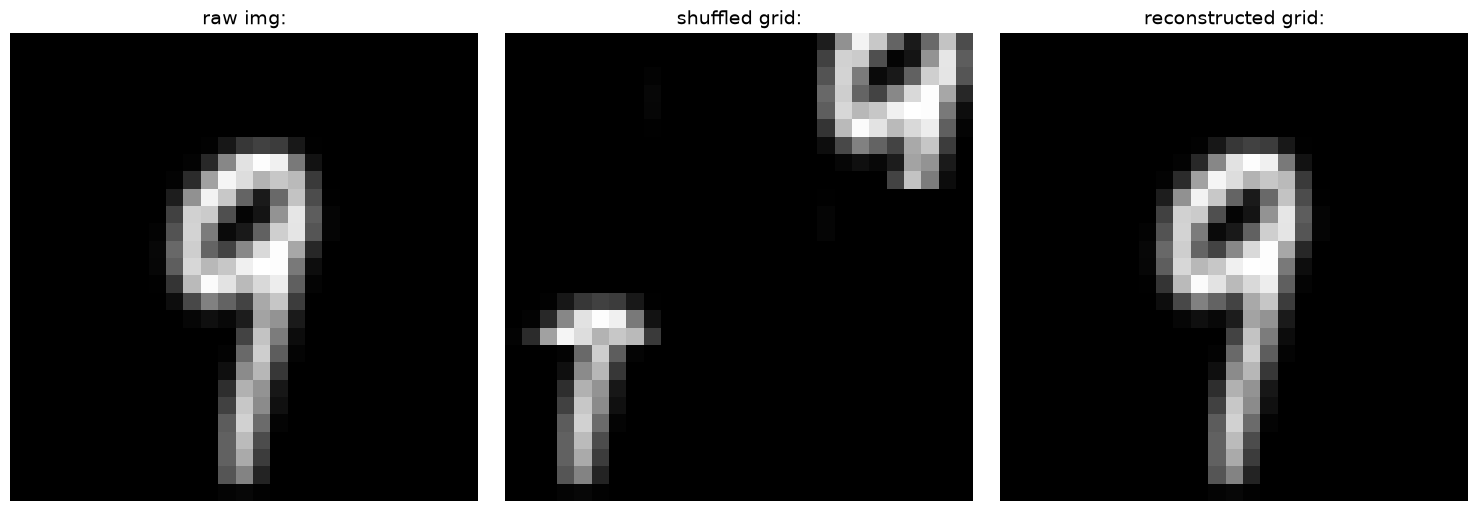

In [250]:
print("======test inference=====")
test_img, _ = train_mini_dataset_3x3[600]
shuffled, target, shuffle_idx = create_mini_puzzle_3x3(test_img)
print(f"random position:{shuffle_idx.numpy()}")
print(f"real position:{target.numpy()}")

predition_order,prediction_value = reconstruction_3x3(puzz_unet, frag_feature_extractor, puzz_scheduler,shuffled, numsteps = 50)
print(f"prediced order of model:{predition_order}")

visualize_reconstruction(test_img,shuffled.numpy(),shuffle_idx,predition_order)